In [1]:
import pandas as pd


In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

# step1:load the data  from excel sheet in jupiter notebook

In [4]:
df=pd.read_excel('pima-data (2).xlsx')
df

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
0,6,148,72,35,0,33.6,0.627,50,1,1.3790,True,True
1,1,85,66,29,0,26.6,0.351,31,0,1.1426,False,False
2,8,183,64,0,0,23.3,0.672,32,1,0.0000,True,True
3,1,89,66,23,94,28.1,0.167,21,0,0.9062,False,False
4,0,137,40,35,168,43.1,2.288,33,1,1.3790,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,1.8912,False,False
764,2,122,70,27,0,36.8,0.340,27,0,1.0638,False,False
765,5,121,72,23,112,26.2,0.245,30,0,0.9062,False,False
766,1,126,60,0,0,30.1,0.349,47,1,0.0000,True,True


In [5]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


## Step2:let us find duplicates columns or co-related coloums

In [6]:
#first check how many columns are there--->

In [7]:
def plot_corr(df, size=11):
    corr = df.corr()  #pandas data frame corelation function
    fig, ax=plt.subplots(figsize=(size,size))
    ax.matshow(corr) #color code the rectangle by corelation values
    plt.xticks(range(len(corr.columns)), corr.columns)
    plt.yticks(range(len(corr.columns)), corr.columns)

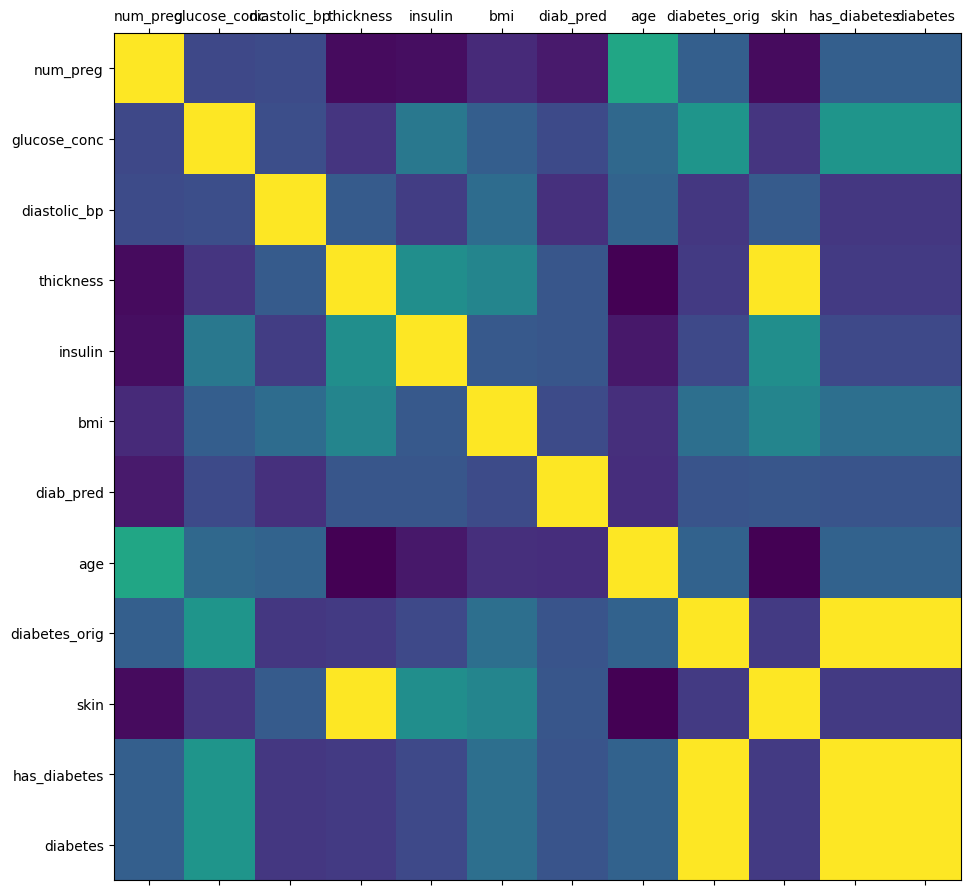

In [8]:
#lets call above function
plot_corr(df)

In [9]:
# we are going to remove thickness, diabetes_orig,has_diabetes

In [10]:
del df['thickness']
del df['has_diabetes']
del df['diabetes_orig']

In [11]:
df.head()

,num_preg,glucose_conc,diastolic_bp,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,0,33.6,0.627,50,1.3790,True
1,1,85,66,0,26.6,0.351,31,1.1426,False
2,8,183,64,0,23.3,0.672,32,0.0000,True
3,1,89,66,94,28.1,0.167,21,0.9062,False
4,0,137,40,168,43.1,2.288,33,1.3790,True


 ### 2.c-lets convert text to numbers

machine learning algorithms will not understand text.so,convert to numbers.

In [12]:
diabetes_map={True:1,False:0}
df['diabetes']=df['diabetes'].map(diabetes_map)

In [13]:
df.head()

,num_preg,glucose_conc,diastolic_bp,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,0,33.6,0.627,50,1.3790,1
1,1,85,66,0,26.6,0.351,31,1.1426,0
2,8,183,64,0,23.3,0.672,32,0.0000,1
3,1,89,66,94,28.1,0.167,21,0.9062,0
4,0,137,40,168,43.1,2.288,33,1.3790,1


## let us  check proportion of diabetes vs non diabetes data

we need to ensure that the proportion should be balanced(50-50)diabetes and non-diabetes or atleast close enough to proceed

In [14]:
num_true=len(df.loc[df['diabetes'] == True])
num_false=len(df.loc[df['diabetes'] == False])
print('true = ',(num_true/ (num_true+num_false) )*100) # it will give true percentage
print('false = ',(num_false/ (num_true+num_false) )*100) # it will give false percentage

true =  34.89583333333333
false =  65.10416666666666


##### Incase of data imbalance we use SMOTE technique to increase lesser data samples

#### let us split our data for training and testing the algorithm

In [15]:
from sklearn.model_selection import train_test_split
input_columns = ['num_preg','glucose_conc','diastolic_bp','insulin','bmi','diab_pred','age','skin']
output_columns = ['diabetes']
x = df[input_columns].values #predicting feature coloumns
y = df[output_columns].values
spilt_test_size = 0.30 
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = spilt_test_size,random_state=42)

In [16]:
#make sure training data and testing data is 70% and 30%
print('{0:0.2f}% in training set'.format( (len(x_train)/len(df.index))*100 ))
print('{0:0.2f}% in testing set'.format( (len(x_test)/len(df.index))*100 ))

69.92% in training set
30.08% in testing set


In [17]:
total_num_preg = len(df.loc[df['num_preg']== 0])
print(f'number of Rows missing in num_preg column is {total_num_preg}')

total_glucose_conc = len(df.loc[df['glucose_conc']==0])
print(f'number of Rows missing in glucose_conc column is {total_glucose_conc}')
total_diastolic_bp = len(df.loc[df['diastolic_bp']==0])
print(f'number of Rows missing in diastolic_bp column is {total_diastolic_bp}')
total_insulin = len(df.loc[df['insulin']==0])
print(f'number of Rows missing in insulin column is {total_insulin}')
total_bmi = len(df.loc[df['bmi']==0])
print(f'number of Rows missing in bmi column is {total_bmi}')
total_diab_pred = len(df.loc[df['diab_pred']==0])
print(f'number of Rows missing in diab_pred column is {total_diab_pred}')
total_age = len(df.loc[df['age'] ==0])
print(f'number of rows missing in age is {total_age}')

number of Rows missing in num_preg column is 111
number of Rows missing in glucose_conc column is 5
number of Rows missing in diastolic_bp column is 35
number of Rows missing in insulin column is 374
number of Rows missing in bmi column is 11
number of Rows missing in diab_pred column is 0
number of rows missing in age is 0


In [18]:
from sklearn.impute import SimpleImputer
fill_zeros = SimpleImputer(missing_values=0,strategy='mean')
#fill_zeros = SimpleImputer(missing_values=0,strategy='mean',axis=0)
x_train = fill_zeros.fit_transform(x_train)
x_test = fill_zeros.fit_transform(x_test)

In [19]:
x_train[0:10]

array([[1.00000000e+00, 9.50000000e+01, 6.00000000e+01, 5.80000000e+01,
        2.39000000e+01, 2.60000000e-01, 2.20000000e+01, 7.09200000e-01],
       [5.00000000e+00, 1.05000000e+02, 7.20000000e+01, 3.25000000e+02,
        3.69000000e+01, 1.59000000e-01, 2.80000000e+01, 1.14260000e+00],
       [4.34056399e+00, 1.35000000e+02, 6.80000000e+01, 2.50000000e+02,
        4.23000000e+01, 3.65000000e-01, 2.40000000e+01, 1.65480000e+00],
       [4.00000000e+00, 1.31000000e+02, 6.80000000e+01, 1.66000000e+02,
        3.31000000e+01, 1.60000000e-01, 2.80000000e+01, 8.27400000e-01],
       [1.00000000e+00, 1.03000000e+02, 3.00000000e+01, 8.30000000e+01,
        4.33000000e+01, 1.83000000e-01, 3.30000000e+01, 1.49720000e+00],
       [2.00000000e+00, 8.20000000e+01, 5.20000000e+01, 1.15000000e+02,
        2.85000000e+01, 1.69900000e+00, 2.50000000e+01, 8.66800000e-01],
       [3.00000000e+00, 1.28000000e+02, 7.80000000e+01, 1.55333333e+02,
        2.11000000e+01, 2.68000000e-01, 5.50000000e+01, 1.

 # Training data

In [20]:
from sklearn.naive_bayes import GaussianNB
#create gaussian naive bayes model object and train it with data
nb_model = GaussianNB()
nb_model.fit(x_train,y_train.ravel())

GaussianNB()

In [21]:
#lets test the algorithm's accuracy with training data itself.
nb_predict_train = nb_model.predict(x_train) # Testing a model
from sklearn import metrics
#accuracy
print('accuracy:{0:.4f}'.format(metrics.accuracy_score(y_train,nb_predict_train)))

accuracy:0.7542


# step5-Testing model

In [22]:
nb_predict_test = nb_model.predict(x_test) # Testing a model
from sklearn import metrics
#accuracy
print('accuracy:{0:.4f}'.format(metrics.accuracy_score(y_test,nb_predict_test)))

accuracy:0.7359


# step6- Analyze the model Accuracy

### with the help of "confusion matrix"we can analyzeb Algorithm performance

In [23]:
print('confusion matrix')
print('{0}'.format(metrics.confusion_matrix(y_test, nb_predict_test)))
print('')
print('classification report')
print(metrics.classification_report(y_test,nb_predict_test))

confusion matrix
[[118  33]
 [ 28  52]]

classification report
              precision    recall  f1-score   support

           0       0.81      0.78      0.79       151
           1       0.61      0.65      0.63        80

    accuracy                           0.74       231
   macro avg       0.71      0.72      0.71       231
weighted avg       0.74      0.74      0.74       231



### let us try random forest algorithm

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train.ravel())
rf_predict_test = rf_model.predict(x_test)
#training metrices
print('accuracy : {0:4f}'.format(metrics.accuracy_score(y_test,rf_predict_test)))


accuracy : 0.753247


In [25]:
#let us confusion matrix and classification report

In [26]:

print(metrics.confusion_matrix(y_test, rf_predict_test))
print('')
print('classification report')
print(metrics.classification_report(y_test, rf_predict_test))

[[120  31]
 [ 26  54]]

classification report
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       151
           1       0.64      0.68      0.65        80

    accuracy                           0.75       231
   macro avg       0.73      0.73      0.73       231
weighted avg       0.76      0.75      0.75       231



In [27]:
#let us try logistic regression algorithm

In [44]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(class_weight='balanced',C=0.2, random_state = 42) # c is a hyperparameter
lr_model.fit(x_train, y_train.ravel())
lr_predict_test = lr_model.predict(x_test)
#training metrices
print('accuracy : {0:4f}'.format(metrics.accuracy_score(y_test,lr_predict_test)))
print('')
print(metrics.confusion_matrix(y_test, lr_predict_test))
print('')
print('classification report')
print(metrics.classification_report(y_test, lr_predict_test))


accuracy : 0.714286

[[111  40]
 [ 26  54]]

classification report
              precision    recall  f1-score   support

           0       0.81      0.74      0.77       151
           1       0.57      0.68      0.62        80

    accuracy                           0.71       231
   macro avg       0.69      0.71      0.70       231
weighted avg       0.73      0.71      0.72       231



C:\Users\Harshi\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## final conclusion-we are suggesting random forest algorithm for this project as the acuuracy is 75% and recall value is 82% which is higher than other 2 algorithms(i.e naive bayes and logistic regression algorithm) 

